## Get Ghana Map + Hospitals, Clinics

Let's start Upper East Region for now. We will expand to the other regions later

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd

place = "Upper East Region, Ghana"

tags = {
    "amenity": ["hospital", "clinic"]
}

facilities = ox.features_from_place(place, tags)

facilities = facilities[["geometry", "name", "amenity"]]
facilities = facilities.dropna(subset=["geometry"])
facilities = facilities.reset_index(drop=True)

print(f"Total facilities: {len(facilities)}")
facilities.head()

Total facilities: 29


,geometry,name,amenity
0,POINT (-1.19267 10.57269),Chansa CHPS,clinic
1,POINT (-1.24661 10.32759),Gbedembilisi CHPS,clinic
2,POINT (-1.22848 10.48019),Uwasa CHPS,clinic
3,POINT (-1.33608 10.36876),Wiesi CHPS,clinic
4,POINT (-0.69316 10.77926),Duusi CHPS Compound,clinic


Facility locations derived from polygons were converted to centroids, which may introduce small spatial inaccuracies

In [3]:
facilities["geometry"] = facilities["geometry"].apply(
    lambda geom: geom.centroid if geom.geom_type != "Point" else geom
)

## Convert everything to points


In [4]:
facilities.geom_type.value_counts()

Point    29
Name: count, dtype: int64

## Clean + reset

In [5]:
facilities = facilities.dropna(subset=["geometry"])
facilities = facilities.reset_index(drop=True)

## Save clean version

In [6]:
facilities.to_file("../data/upper_east_facilities.geojson", driver="GeoJSON")

## Quick plot check

<Axes: >

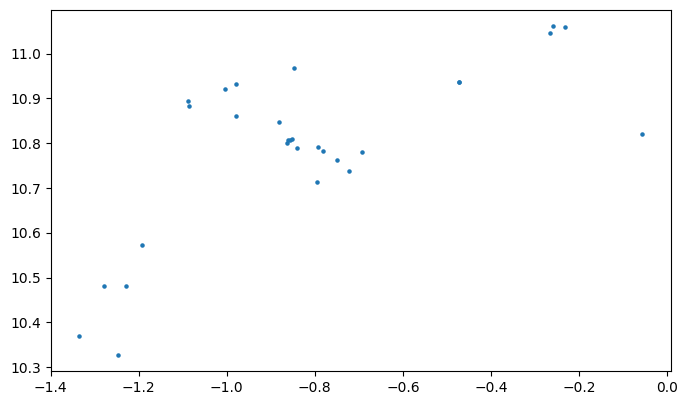

In [7]:
facilities.plot(figsize=(8,8), markersize=5)